In [391]:
import pandas as pd
import mne
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
import functools
import scipy.stats as ss
import seaborn as sns

In [392]:
df = pd.read_csv('/Users/piotrblaszyk/Documents/university/MRIGI/sensors-70005/cw-2/data/MainTask/SPNDataChallenge0001.csv')
print(df.head())

   subject  session  data_source  structured_data  channel  signal  stimulus  \
0      101        1            1                1        1       1         1   
1      101        1            1                1        1       2         1   
2      101        1            1                1        2       1         1   
3      101        1            1                1        2       2         1   
4      101        1            1                1        4       1         1   

   block  mean_baseline  std_baseline  mean_task  std_task  \
0      1      -0.079285        3.2234   2.022500    6.8620   
1      1      -0.621910        1.4858  -0.047585    2.0509   
2      1       1.693600        5.6047   0.659910    7.6422   
3      1      -0.479970        1.3901  -0.076588    1.5310   
4      1       1.961100        3.8321   0.660960    5.8071   

   task_minus_baseline  area_under_curve_task  time_to_peak  time_to_nadir  
0              2.10180               111.1100            22          

### Analyse primary columns

In [393]:
col_names = list(df.columns)
print(", ".join(col_names))
primary_col_names = col_names[:8]
total = 1
total_const = 8208
for primary_col_name in primary_col_names:
    col_entries = list(set(df[primary_col_name]))
    col_entries.sort()
    if len(col_entries) > 1:
        total *= len(col_entries)
        print(len(col_entries))
        print(primary_col_name)
        print(col_entries)
        print("expected length", total_const / len(col_entries))
        all_num_entries = []
        for col_entry in col_entries:
            num_entries = len(df[df[primary_col_name] == col_entry])
            all_num_entries.append(num_entries)
            print(col_entry, num_entries)
        all_num_entries.sort(reverse=True)
        print(all_num_entries)
        print()

print(total)
print(len(df))

subject, session, data_source, structured_data, channel, signal, stimulus, block, mean_baseline, std_baseline, mean_task, std_task, task_minus_baseline, area_under_curve_task, time_to_peak, time_to_nadir
57
subject
[101, 102, 104, 105, 106, 108, 109, 112, 113, 114, 115, 116, 118, 120, 124, 125, 129, 131, 201, 202, 203, 204, 205, 206, 207, 208, 210, 211, 212, 213, 214, 216, 217, 218, 219, 220, 221, 224, 225, 301, 302, 303, 304, 306, 307, 309, 310, 311, 312, 314, 315, 316, 317, 319, 324, 328, 329]
expected length 144.0
101 26
102 42
104 32
105 42
106 34
108 42
109 42
112 48
113 48
114 8
115 42
116 24
118 34
120 2
124 44
125 18
129 40
131 42
201 30
202 34
203 38
204 30
205 6
206 36
207 48
208 12
210 46
211 42
212 46
213 42
214 20
216 36
217 36
218 42
219 46
220 42
221 36
224 48
225 32
301 20
302 12
303 26
304 8
306 16
307 16
309 10
310 20
311 30
312 16
314 32
315 14
316 40
317 14
319 8
324 28
328 10
329 12
[48, 48, 48, 48, 46, 46, 46, 44, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 40, 40, 38

### Define constants

In [394]:
oxy_mask = df['signal'] == 1
deoxy_mask = df['signal'] == 2

right_mask = df['channel'] <= 12
left_mask = df['channel'] >= 13
hemisphere_masks = [
    right_mask,
    left_mask
]

hemisphere_names = [
    "right",
    "left"
]

consultant_mask = df['session'] == 1
registrar_mask = df['session'] == 2
novice_mask = df['session'] == 3

experience_masks = [
    consultant_mask,
    registrar_mask,
    novice_mask
]

experience_names = [
    'consultant',
    'registrar',
    'novice'
]

experience_letters = [
    'C',
    'R',
    'N'
]

right_channels = np.arange(1, 13)
left_channels = np.array([14, 13, 17, 16, 15, 19, 18, 22, 21, 20, 24, 23])
all_channels = np.arange(1, 25)
hemisphere_channels = [
    right_channels,
    left_channels
]

channel_array_right_hemisphere = [
    ['FC4', 12, None, 11, 'F2'],
    [10, None, 9, None, 8],
    ['FC6', 7, 'F4', 6, None],
    [5, None, 4, None, 3],
    ['F8', 2, 'AF8', 1, 'Fp2']
]

channel_array_left_hemisphere = [
    ['F1', 24, None, 23, 'FC3'],
    [22, None, 21, None, 20],
    [None, 19, 'F3', 18, 'FC5'],
    [17, None, 16, None, 15],
    ['Fp1', 14, 'AF7', 13, 'F7']
]

channel_array_right_hemisphere_2 = np.array([
    [np.nan, 12, np.nan, 11, np.nan],
    [10, np.nan, 9, np.nan, 8],
    [np.nan, 7, np.nan, 7, np.nan],
    [5, np.nan, 4, np.nan, 3],
    [np.nan, 2, np.nan, 1, np.nan]
])

channel_array_left_hemisphere_2 = np.array([
    [np.nan, 24, np.nan, 23, np.nan],
    [22, np.nan, 21, np.nan, 20],
    [np.nan, 19, np.nan, 18, np.nan],
    [17, np.nan, 16, np.nan, 15],
    [np.nan, 14, np.nan, 13, np.nan]
])

channel_array_hemispheres = [
    channel_array_right_hemisphere_2,
    channel_array_left_hemisphere_2
]

orbital_left_ch = [14, 17]
orbital_right_ch = [1, 3]
lateral_left_ch = [13, 15, 16, 18, 19, 21]
lateral_right_ch = [2, 4, 5, 6, 7, 9]
orbital_ch = orbital_left_ch + orbital_right_ch
lateral_ch = lateral_left_ch + lateral_right_ch
together = [
    orbital_ch,
    lateral_ch
]
together_names = [
    'orbital',
    'lateral'
]

together_masks = []
for area in together:
    area_masks = []
    for channel_num in area:
        area_masks.append(df['channel'] == channel_num)
    area_mask = functools.reduce(lambda x, y: x | y, area_masks)
    together_masks.append(area_mask)

neutral_mask = pd.Series(True, index=df.index)

In [395]:
def my_str(arr):
    return " ".join([f"{x:.1f}" for x in arr])

def my_str_2(arr):
    return " ".join([f"{x:.2f}" for x in arr])

def check_two_sample_t_test_assumptions(data1, data2):
    """
    Checks the assumptions for a two-sample t-test:
    1. Normality of the data in each group
    2. Homogeneity of variances (equal variances)

    Args:
        data1: The first sample of data.
        data2: The second sample of data.

    Returns:
        A tuple containing:
            - normality_passed: True if both samples are approximately normal, False otherwise.
            - equal_variance_passed: True if the variances are approximately equal, False otherwise.
    """

    # Check for normality using Shapiro-Wilk test
    normality_passed1 = ss.shapiro(data1).pvalue > 0.05
    normality_passed2 = ss.shapiro(data2).pvalue > 0.05
    normality_passed = normality_passed1 and normality_passed2

    # Check for equal variances using Levene's test
    equal_variance_passed = ss.levene(data1, data2).pvalue > 0.05

    # print('normality_passed1', normality_passed1)
    # print('normality_passed2', normality_passed2)
    # print('equal_variance_passed', equal_variance_passed)

    return normality_passed and equal_variance_passed

### EDA

#### h1

manual analysis

In [396]:
channel_responses = np.zeros(24)
for i in range(len(right_channels)):
    right_channel = right_channels[i]
    left_channel = left_channels[i]
    both_channels = [
        right_channel,
        left_channel
    ]
    both_mean_responses = []
    for channel in both_channels:
        channel_mask = df['channel'] == channel
        responses = df[oxy_mask & channel_mask]['task_minus_baseline']
        mean_response = np.mean(responses)
        both_mean_responses.append(mean_response)
        channel_responses[channel-1] = mean_response
    diff = both_mean_responses[1] - both_mean_responses[0]
    print(" ".join([str(x) for x in both_channels]), "|", " ".join(f"{x:.1f}" for x in both_mean_responses), "|", f"{diff:.1f}")
print()

channel_responses = np.array(channel_responses)
right = channel_responses[:12]
left = channel_responses[12:]
hemisphere_channel_responses = [
    right,
    left
]
for i in range(len(hemisphere_channel_responses)):
    hemisphere_channel_response = hemisphere_channel_responses[i]
    hemisphere_name = hemisphere_names[i]
    hemi_mean = np.mean(hemisphere_channel_response)
    hemi_std = np.std(hemisphere_channel_response)
    print(f"{hemisphere_name} hemisphere channel response")
    print('mean', f"{hemi_mean:.1f}")
    print('std', f"{hemi_std:.1f}")
    print()

1 14 | 2.1 2.4 | 0.2
2 13 | 3.0 3.3 | 0.3
3 17 | 2.6 2.8 | 0.1
4 16 | 2.7 1.7 | -1.0
5 15 | 2.8 0.6 | -2.2
6 19 | 2.7 2.6 | -0.0
7 18 | 2.7 2.3 | -0.4
8 22 | 2.6 2.6 | -0.0
9 21 | 3.3 2.0 | -1.3
10 20 | 3.7 3.0 | -0.7
11 24 | 2.4 2.2 | -0.2
12 23 | 2.8 1.7 | -1.2

right hemisphere channel response
mean 2.8
std 0.4

left hemisphere channel response
mean 2.3
std 0.7



#### h2

#### h3

manual analysis

In [397]:
experience_responses = [df[oxy_mask & mask]['task_minus_baseline'] for mask in experience_masks]
experience_mean_responses = [np.mean(responses) for responses in experience_responses]
print("experience_mean_responses", my_str_2(experience_mean_responses))
print()

print("_ |", "    ".join(experience_letters), "| _")
all_diffs = np.zeros((len(all_channels), 2))

for i in all_channels:
    channel_mask = df['channel'] == i
    channel_experience_responses = []
    for j in range(len(experience_masks)):
        experience_mask = experience_masks[j]
        responses = df[oxy_mask & channel_mask & experience_mask]['task_minus_baseline']
        mean_response = np.mean(responses)
        channel_experience_responses.append(mean_response)
    amplitude = max(channel_experience_responses) - min(channel_experience_responses)
    diffs = np.diff(channel_experience_responses)
    all_diffs[i-1] = diffs
    print(i, "|", my_str(channel_experience_responses), "|", my_str(diffs), "|", f"{amplitude:.1f}")
print()
diff_means = np.mean(all_diffs, axis=0)
print("diff_means", diff_means)
print()

experience_mean_responses 2.53 2.37 2.97

_ | C    R    N | _
1 | 2.6 2.6 0.1 | 0.0 -2.5 | 2.5
2 | 1.3 2.5 8.4 | 1.3 5.8 | 7.1
3 | 3.8 2.5 1.4 | -1.3 -1.1 | 2.5
4 | 1.8 2.4 4.9 | 0.6 2.5 | 3.1
5 | 1.0 1.8 8.7 | 0.8 6.9 | 7.7


6 | 3.1 2.5 2.2 | -0.6 -0.3 | 0.9
7 | 3.1 1.8 4.0 | -1.3 2.3 | 2.3
8 | 2.9 2.5 2.6 | -0.4 0.1 | 0.4
9 | 3.6 2.9 3.7 | -0.8 0.8 | 0.8
10 | 2.6 1.9 8.8 | -0.7 6.9 | 6.9
11 | 3.3 2.2 1.1 | -1.1 -1.1 | 2.2
12 | 3.9 2.6 1.9 | -1.3 -0.7 | 2.0
13 | 1.9 0.8 18.3 | -1.1 17.5 | 17.5
14 | 2.6 3.1 -0.0 | 0.5 -3.2 | 3.2
15 | -0.4 -0.1 13.5 | 0.3 13.6 | 13.9
16 | 1.8 1.8 0.9 | -0.0 -0.9 | 0.9
17 | 3.5 3.0 1.3 | -0.6 -1.7 | 2.3
18 | 1.8 1.7 4.4 | -0.0 2.7 | 2.7
19 | 2.7 2.0 4.1 | -0.7 2.1 | 2.1
20 | 2.1 4.1 4.0 | 2.1 -0.2 | 2.1
21 | 2.2 2.4 0.9 | 0.2 -1.5 | 1.5
22 | 3.4 2.7 0.4 | -0.7 -2.3 | 3.0
23 | 1.6 3.1 -0.2 | 1.5 -3.3 | 3.3
24 | 2.8 2.4 0.8 | -0.4 -1.7 | 2.1

diff_means [-0.2  1.7]



### Visualise data

#### Histograms

h1

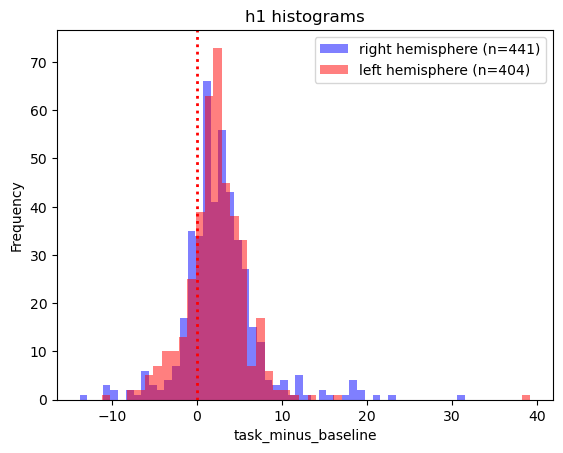

In [398]:
h1_responses = [df[oxy_mask & x]["task_minus_baseline"] for x in hemisphere_masks]

# Plot histograms
plt.hist(h1_responses[0], bins=50, alpha=0.5, color='blue', label=f"{hemisphere_names[0]} hemisphere (n={len(h1_responses[0])})")  # 50% transparent blue bars
plt.hist(h1_responses[1], bins=50, alpha=0.5, color='red', label=f"{hemisphere_names[1]} hemisphere (n={len(h1_responses[1])})")   # 50% transparent red bars
plt.axvline(x=0, color='red', linestyle=':', linewidth=2)

# Add labels and legend
plt.xlabel('task_minus_baseline')
plt.ylabel('Frequency')
plt.title('h1 histograms')
plt.legend()

# Show the plot
plt.show()

h2

[28, 72]


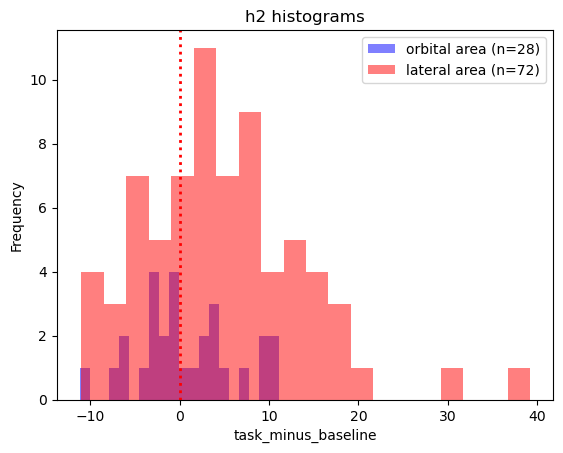

In [399]:
h2_responses = [df[oxy_mask & novice_mask & mask]['task_minus_baseline'] for mask in together_masks]

print([len(x) for x in h2_responses])

# Plot histograms
plt.hist(h2_responses[0], bins=20, alpha=0.5, color='blue', label=f"{together_names[0]} area (n={len(h2_responses[0])})")  # 50% transparent blue bars
plt.hist(h2_responses[1], bins=20, alpha=0.5, color='red', label=f"{together_names[1]} area (n={len(h2_responses[1])})")   # 50% transparent red bars
plt.axvline(x=0, color='red', linestyle=':', linewidth=2)

# Add labels and legend
plt.xlabel('task_minus_baseline')
plt.ylabel('Frequency')
plt.title('h2 histograms')
plt.legend()

# Show the plot
plt.show()

h3

[305, 374, 166]


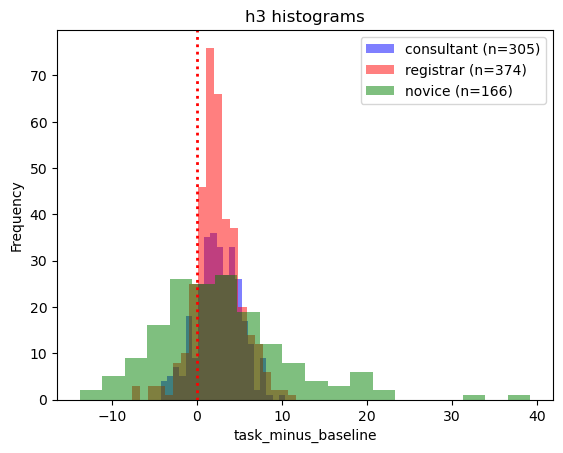

In [400]:
h3_responses = [df[oxy_mask & mask]['task_minus_baseline'] for mask in experience_masks]

print([len(x) for x in h3_responses])

# Plot histograms
plt.hist(h3_responses[0], bins=20, alpha=0.5, color='blue', label=f"{experience_names[0]} (n={len(h3_responses[0])})")  # 50% transparent blue bars
plt.hist(h3_responses[1], bins=20, alpha=0.5, color='red', label=f"{experience_names[1]} (n={len(h3_responses[1])})")   # 50% transparent red bars
plt.hist(h3_responses[2], bins=20, alpha=0.5, color='green', label=f"{experience_names[2]} (n={len(h3_responses[2])})")   # 50% transparent green bars
plt.axvline(x=0, color='red', linestyle=':', linewidth=2)

# Add labels and legend
plt.xlabel('task_minus_baseline')
plt.ylabel('Frequency')
plt.title('h3 histograms')
plt.legend()

# Show the plot
plt.show()

#### Heat maps

preamble

In [401]:
# Function to replace integers with data values
def fill_channel_array(channel_array, data):
    res = np.zeros_like(channel_array)
    for i in range(channel_array.shape[0]):
        for j in range(channel_array.shape[1]):
            x = channel_array[i][j]
            if not np.isnan(x):
                res[i][j] = data[int(x) - 1]
            else:
                res[i][j] = np.nan
    return res

overall

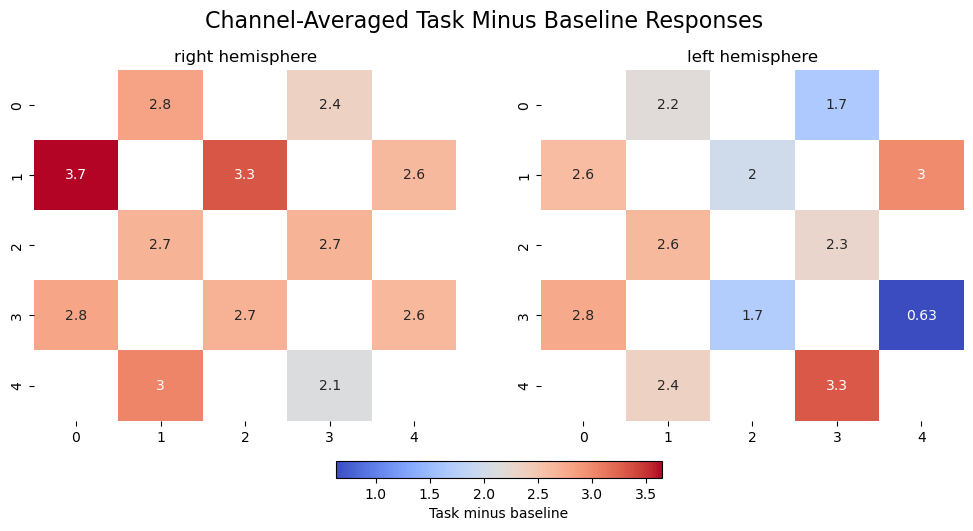

In [402]:
def plot_heatmap(experience_ix=None):
    np.set_printoptions(precision=1)
    experience_mask = experience_masks[experience_ix] if experience_ix is not None else neutral_mask
    experience_name = f" - {experience_names[experience_ix]}" if experience_ix is not None else ""
    overall_channel_responses = np.array([np.mean(df[oxy_mask & (df['channel'] == i) & experience_mask]['task_minus_baseline']) for i in all_channels])

    channel_arrays_filled = [fill_channel_array(x, overall_channel_responses) for x in channel_array_hemispheres]

    # Get global min and max values across all arrays for consistent scaling
    vmin = np.nanmin([np.nanmin(arr) for arr in channel_arrays_filled])
    vmax = np.nanmax([np.nanmax(arr) for arr in channel_arrays_filled])

    # Create a 1x2 subplot
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Loop through each hemisphere and plot on the respective axis
    for i, ax in enumerate(axes):
        sns.heatmap(
            channel_arrays_filled[i], 
            annot=True, 
            cmap='coolwarm', 
            cbar=False,  # Disable individual colorbars
            ax=ax, 
            vmin=vmin, 
            vmax=vmax
        )
        ax.set_title(f'{hemisphere_names[i]} hemisphere')

    # Adjust the layout to allocate space below for the colorbar
    fig.subplots_adjust(bottom=0.2)

    # Add a shared horizontal colorbar below the subplots
    cbar = fig.colorbar(
        plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=vmin, vmax=vmax)), 
        ax=axes, 
        orientation='horizontal', 
        fraction=0.04, 
        pad=0.1
    )
    cbar.set_label('Task minus baseline')

    # Add a super title for the entire figure
    fig.suptitle(f'Channel-Averaged Task Minus Baseline Responses{experience_name}', fontsize=16)

    # Show the plot
    plt.show()

plot_heatmap()

experience-wise

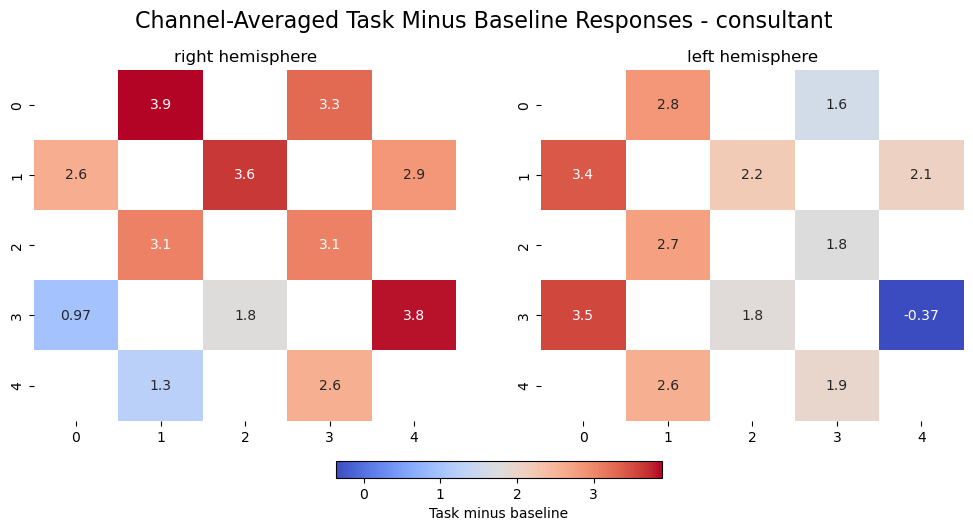

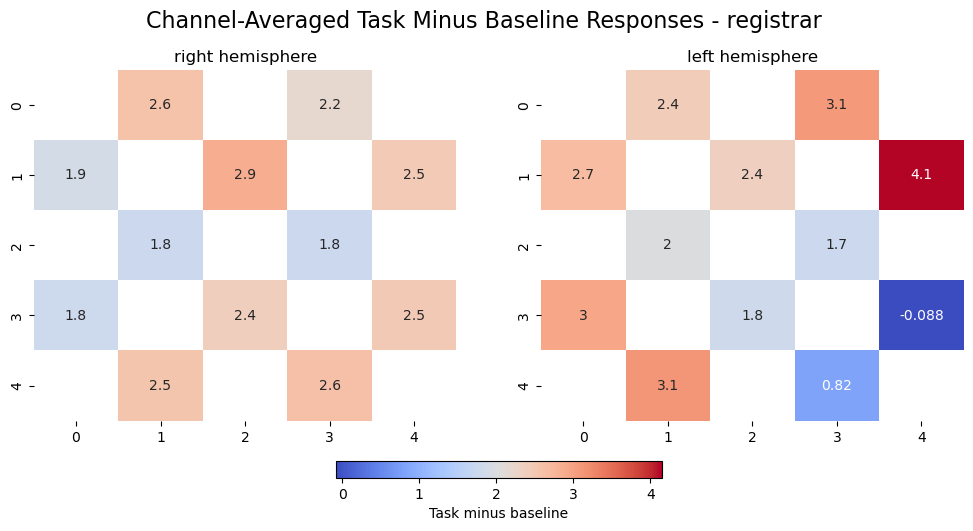

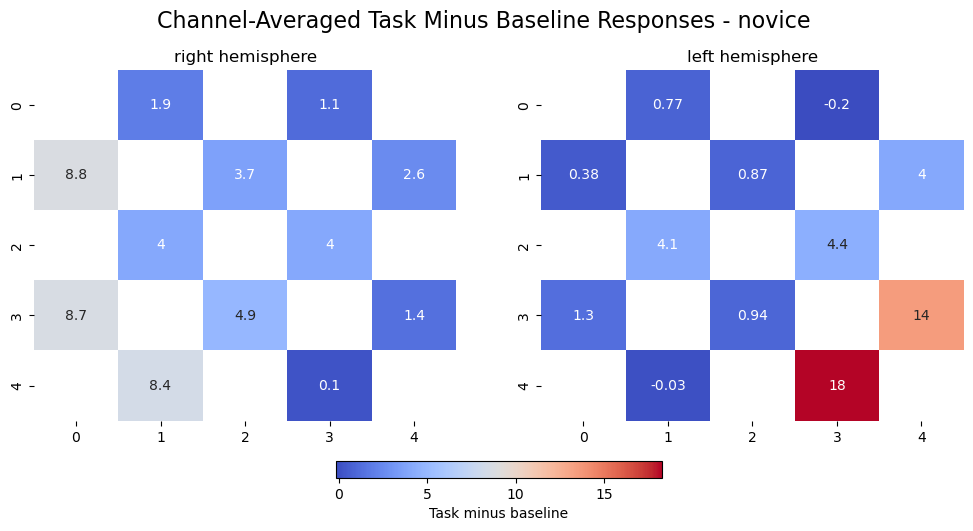

In [403]:
for i in range(len(experience_masks)):
    plot_heatmap(i)

### Hypothesis 1: The task induces a lateralized response.

fine-grained

In [404]:
hemisphere_reponses_with_subject = [df[oxy_mask & mask][['subject', 'task_minus_baseline']] for mask in hemisphere_masks]
hemisphere_reponses = [x['task_minus_baseline'] for x in hemisphere_reponses_with_subject]
for hemisphere_response in hemisphere_reponses:
    print(len(hemisphere_response))
t_stat, p_value = ss.ttest_ind(hemisphere_reponses[0], hemisphere_reponses[1], equal_var=False)
print(f"t_stat {t_stat:.3f}")
print(f"p_value {p_value:.3f}")
print()

441
404
t_stat 1.648
p_value 0.100



channel-wise

In [405]:
channel_t_stats = []
channel_p_values = []
for i in range(len(right_channels)):
    both_responses = []
    for channel_list in hemisphere_channels:
        channel = channel_list[i]
        channel_mask = df['channel'] == channel
        channel_responses = df[oxy_mask & channel_mask]['task_minus_baseline']
        both_responses.append(channel_responses)
    res = check_two_sample_t_test_assumptions(both_responses[0], both_responses[1])
    if res:
        print("Success! Can run t test!")
    else:
        print("Failure. Can't run t test.")
    t_stat, p_value = ss.ttest_ind(both_responses[0], both_responses[1], equal_var=False)
    channel_t_stats.append(t_stat)
    channel_p_values.append(p_value)
n_comparisons = len(channel_p_values)
corrected_p_values = np.minimum(np.array(channel_p_values) * n_comparisons, 1.0)
print("Original p-values:", my_str_2(channel_p_values))
print("Corrected p-values:", my_str_2(corrected_p_values))
print("t-test values (unchanged):", my_str_2(channel_t_stats))
aggregate_p_value = np.min(corrected_p_values)
aggregate_t_stat = np.max(channel_t_stats)
print("Aggregate p-value (most significant after correction):", f"{aggregate_p_value:.2f}")
print("Aggregate t-statistic (max):", f"{aggregate_t_stat:.2f}")
print()

Success! Can run t test!
Failure. Can't run t test.
Failure. Can't run t test.
Failure. Can't run t test.
Failure. Can't run t test.
Failure. Can't run t test.
Failure. Can't run t test.
Failure. Can't run t test.
Success! Can run t test!
Failure. Can't run t test.
Failure. Can't run t test.
Failure. Can't run t test.
Original p-values: 0.75 0.89 0.89 0.24 0.19 0.95 0.76 0.97 0.09 0.61 0.79 0.22
Corrected p-values: 1.00 1.00 1.00 1.00 1.00 1.00 1.00 1.00 1.00 1.00 1.00 1.00
t-test values (unchanged): -0.32 -0.14 -0.14 1.18 1.33 0.06 0.31 0.03 1.73 0.51 0.27 1.22
Aggregate p-value (most significant after correction): 1.00
Aggregate t-statistic (max): 1.73



experience-wise

In [406]:
for i in range(len(experience_masks)):
    experience_mask = experience_masks[i]
    experience_name = experience_names[i]
    hemisphere_reponses = [df[oxy_mask & experience_mask & mask]['task_minus_baseline'] for mask in hemisphere_masks]
    for hemisphere_response in hemisphere_reponses:
        print(len(hemisphere_response))
    t_stat, p_value = ss.ttest_ind(hemisphere_reponses[0], hemisphere_reponses[1], equal_var=False)
    print(experience_name)
    print(f"t_stat {t_stat:.2f}")
    print(f"p_value {p_value:.2f}")
    print()

158
147
consultant
t_stat 1.67
p_value 0.10

190
184
registrar
t_stat 0.07
p_value 0.94

93
73
novice
t_stat 1.17
p_value 0.24



subject-averaged

{302, 307, 328, 205, 120}


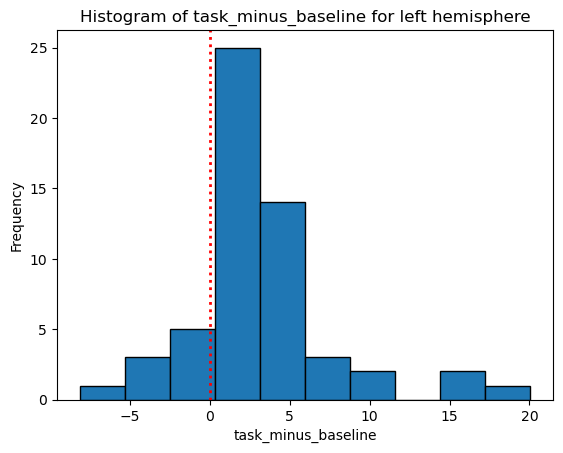

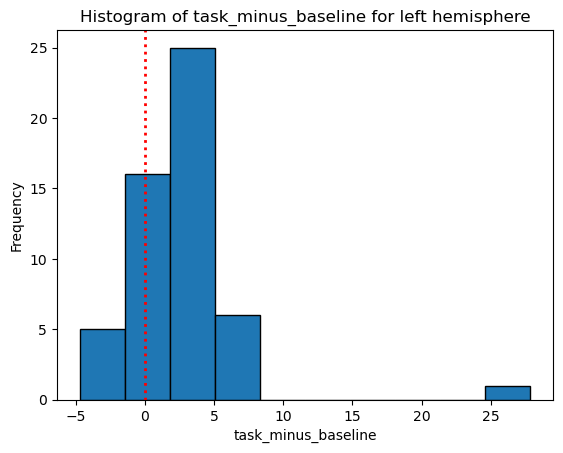

Failure. Can't run t test.
t_stat 0.65
p_value 0.52



In [407]:
hemisphere_subject_averaged_together = [responses.groupby("subject").mean().reset_index() for responses in hemisphere_reponses_with_subject]
hemisphere_subjects = [set(x['subject']) for x in hemisphere_subject_averaged_together]
print(hemisphere_subjects[0] ^ hemisphere_subjects[1])
common_subjects = hemisphere_subjects[0] & hemisphere_subjects[1]
hemisphere_subject_averaged_paired_together = [x[x["subject"].isin(common_subjects)].sort_values(by="subject") for x in hemisphere_subject_averaged_together]
hemisphere_paired_subjects = [set(x['subject']) for x in hemisphere_subject_averaged_paired_together]
assert(hemisphere_paired_subjects[0] == hemisphere_paired_subjects[1])
for x in hemisphere_subject_averaged_together:
    col = 'task_minus_baseline'
    x[col].plot(kind='hist', bins=10, edgecolor='black')

    plt.axvline(x=0, color='red', linestyle=':', linewidth=2)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Histogram of {col} for {hemisphere_name} hemisphere')
    plt.show()
hemisphere_value_only = [x['task_minus_baseline'] for x in hemisphere_subject_averaged_paired_together]
can_do_t_test = check_two_sample_t_test_assumptions(hemisphere_value_only[0], hemisphere_value_only[1])
if can_do_t_test:
    print("Success! Can run t test!")
else:
    print("Failure. Can't run t test.")
t_stat, p_value = ss.ttest_ind(hemisphere_value_only[0], hemisphere_value_only[1], equal_var=False)
print(f"t_stat {t_stat:.2f}")
print(f"p_value {p_value:.2f}")
print()

### Hypothesis 2: In novices, orbital activity is more pronounced than lateral activity.

fine-grained

In [408]:
together_responses = [df[oxy_mask & novice_mask & mask]['task_minus_baseline'] for mask in together_masks]
together_mean_responses = [np.mean(responses) for responses in together_responses]
print(together_mean_responses)

t_stat, p_value = ss.ttest_ind(together_responses[0], together_responses[1], equal_var=False)
print(f"t_stat {t_stat:.3f}")
print(f"p_value {p_value:.3f}")
print()

[0.6766735714285715, 4.783159444444445]
t_stat -2.718
p_value 0.008



### Hypothesis 3: Prefrontal hemodynamic response as monitored with fNIRS is sensitive to surgical expertise.

fine-grained

In [409]:
experience_pairs = [(0, 1), (1, 2), (2, 0)]
for i, j in experience_pairs:
    name_i = experience_names[i]
    name_j = experience_names[j]
    t_stat, p_value = ss.ttest_ind(experience_responses[i], experience_responses[j], equal_var=False)
    print(name_i, name_j)
    print(f"t_stat {t_stat:.3f}")
    print(f"p_value {p_value:.3f}")
    print()

consultant registrar
t_stat 0.815
p_value 0.415

registrar novice
t_stat -0.953
p_value 0.342

novice consultant
t_stat 0.689
p_value 0.492

